In [30]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

import cv2
import numpy as np
import pandas as pd
import torch

from ultralytics import YOLO
from transformers import (
    AutoImageProcessor,
    SegformerForSemanticSegmentation
)

In [33]:
photos_dir = Path("../data/raw_photo_sample")
image_path = sorted(photos_dir.glob("*.jpg"))
random.seed(42)
# selected_image_path = random.sample(image_path, k=3)
selected_image_path = image_path[:3]

print(f"All photos {len(image_path)}")
print("Selected photos: ")
for path in selected_image_path:
    print(f"{path.name}")

All photos 71
Selected photos: 
IM5A4169.jpg
IM5A4174.jpg
IM5A4176.jpg


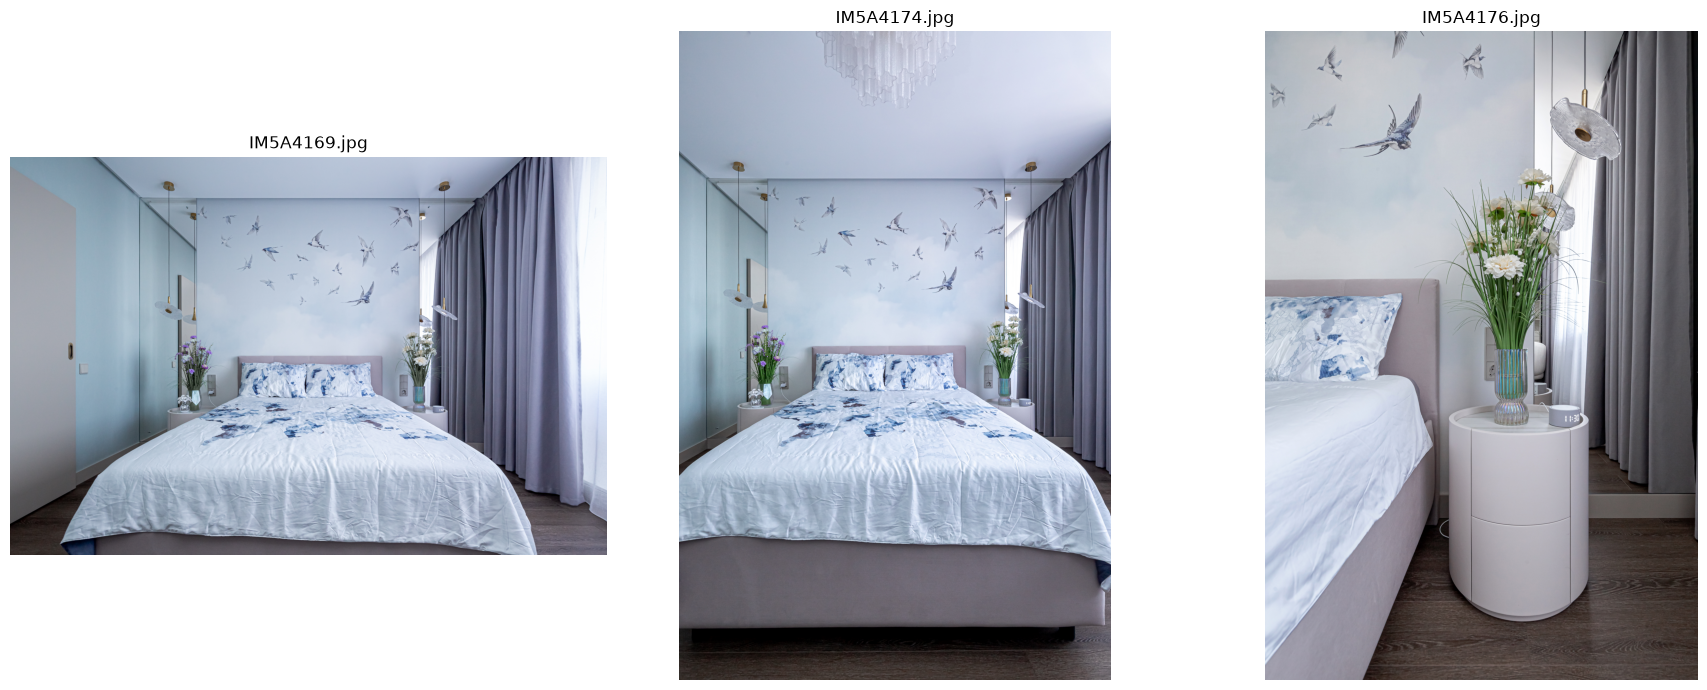

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, image_path in zip(axes, selected_image_path):
    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
yolo_model = YOLO("yolo11m.pt")

segformer_name = "nvidia/segformer-b0-finetuned-ade-512-512"
segformer_processor = AutoImageProcessor.from_pretrained(segformer_name)
segformer_model = SegformerForSemanticSegmentation.from_pretrained(segformer_name)

device = "mps" if torch.backends.mps.is_available else "cpu"

segformer_model.to(device)
segformer_model.eval()

print("Download models is done")
print(f"device is {device}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Download models is done
device is mps


In [35]:
surface_labels = ["wall", "floor", "ceiling"]

segformer_id2label = segformer_model.config.id2label
segformer_label2id = {
    label: class_id
    for class_id, label in segformer_id2label.items()
}

def get_surface_coverage(image_path, max_side=1024):
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((max_side, max_side))

    inputs = segformer_processor(
        images=image,
        return_tensors="pt",
    )
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = segformer_model(**inputs)

    logits = torch.nn.functional.interpolate(
        outputs.logits.cpu(),
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )

    segmentation = logits.argmax(dim=1)[0].numpy()

    coverage = {}

    for label in surface_labels:
        class_id = segformer_label2id[label]
        mask = segmentation == class_id
        coverage[label] = round(float(mask.mean() * 100), 1)

    return coverage

In [36]:
def analyze_room(image_paths, area_m2):
    yolo_results = yolo_model.predict(
        source=[str(path) for path in image_paths],
        conf=0.25,
        save=False,
        verbose=False,
    )

    objects = {}

    for result in yolo_results:
        image_name = Path(result.path).name

        for box in result.boxes:
            class_id = int(box.cls[0])
            label = yolo_model.names[class_id]
            confidence = float(box.conf[0])

            if label not in objects:
                objects[label] = {
                    "detections": 0,
                    "images": set(),
                    "max_confidence": 0.0,
                }

            objects[label]["detections"] += 1
            objects[label]["images"].add(image_name)
            objects[label]["max_confidence"] = max(
                objects[label]["max_confidence"],
                confidence,
            )

    detected_objects = []

    for label, data in objects.items():
        detected_objects.append({
            "label": label,
            "detections": data["detections"],
            "detected_in_images": len(data["images"]),
            "max_confidence": round(data["max_confidence"], 3),
        })

    detected_objects.sort(
        key=lambda item: item["max_confidence"],
        reverse=True,
    )

    surfaces_by_image = {}

    for image_path in image_paths:
        surfaces_by_image[image_path.name] = get_surface_coverage(
            image_path
        )

    average_surface_visibility = {
        label: round(
            float(np.mean([
                surfaces_by_image[image_name][label]
                for image_name in surfaces_by_image
            ])),
            1,
        )
        for label in surface_labels
    }

    return {
        "area_m2": area_m2,
        "images": [path.name for path in image_paths],
        "detected_objects": detected_objects,
        "surfaces_by_image": surfaces_by_image,
        "average_surface_visibility_percent":
            average_surface_visibility,
    }

In [38]:
room_result = analyze_room(
    image_paths=selected_image_path,
    area_m2=5.4,
)

room_result

{'area_m2': 5.4,
 'images': ['IM5A4169.jpg', 'IM5A4174.jpg', 'IM5A4176.jpg'],
 'detected_objects': [{'label': 'bed',
   'detections': 3,
   'detected_in_images': 3,
   'max_confidence': 0.937},
  {'label': 'vase',
   'detections': 6,
   'detected_in_images': 3,
   'max_confidence': 0.849},
  {'label': 'bird',
   'detections': 29,
   'detected_in_images': 3,
   'max_confidence': 0.765},
  {'label': 'kite',
   'detections': 1,
   'detected_in_images': 1,
   'max_confidence': 0.496},
  {'label': 'potted plant',
   'detections': 5,
   'detected_in_images': 3,
   'max_confidence': 0.482},
  {'label': 'refrigerator',
   'detections': 1,
   'detected_in_images': 1,
   'max_confidence': 0.381}],
 'surfaces_by_image': {'IM5A4169.jpg': {'wall': 42.2,
   'floor': 6.2,
   'ceiling': 6.8},
  'IM5A4174.jpg': {'wall': 17.0, 'floor': 9.8, 'ceiling': 20.9},
  'IM5A4176.jpg': {'wall': 28.3, 'floor': 14.0, 'ceiling': 0.0}},
 'average_surface_visibility_percent': {'wall': 29.2,
  'floor': 10.0,
  'ceiling

In [39]:
useful_object_labels = {
    "bed",
    "couch",
    "chair",
    "dining table",
    "tv",
    "sink",
    "toilet",
    "refrigerator",
    "oven",
    "microwave",
}

def filter_detected_objects(
    detected_objects,
    min_confidence=0.5,
    min_images=2,
):
    return [
        item
        for item in detected_objects
        if item["label"] in useful_object_labels
        and item["max_confidence"] >= min_confidence
        and item["detected_in_images"] >= min_images
    ]

In [40]:
room_result["filtered_objects"] = filter_detected_objects(
    room_result["detected_objects"]
)

room_result["filtered_objects"]

[{'label': 'bed',
  'detections': 3,
  'detected_in_images': 3,
  'max_confidence': 0.937}]

In [41]:
def infer_room_type(filtered_objects):
    labels = {
        item["label"]
        for item in filtered_objects
    }

    if "toilet" in labels:
        return "bathroom"

    if labels & {"oven", "refrigerator", "microwave"}:
        return "kitchen"

    if "bed" in labels:
        return "bedroom"

    if labels & {"couch", "tv"}:
        return "living_room"

    return "unknown"

In [42]:
room_result["probable_room_type"] = infer_room_type(
    room_result["filtered_objects"]
)

print(room_result["probable_room_type"])

bedroom
